In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_excel('simple_linear_regression_beginner_data.xlsx')

In [3]:
df.head()

,Hours_Studied,Exam_Score
0,1.0,35
1,1.5,38
2,2.0,42
3,2.5,45
4,3.0,48


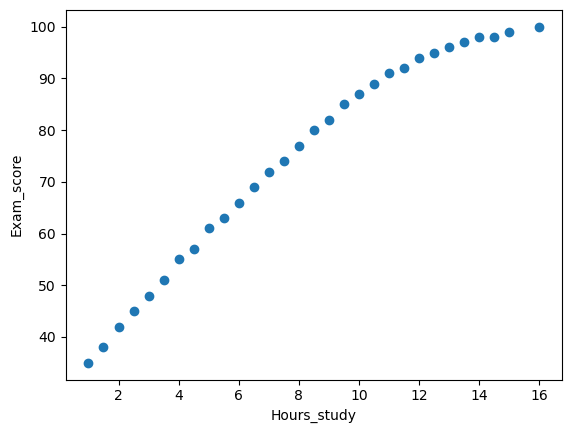

In [4]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel('Hours_study')
plt.ylabel('Exam_score')
plt.show()

In [5]:
df.corr()

,Hours_Studied,Exam_Score
Hours_Studied,1.000000,0.981676
Exam_Score,0.981676,1.000000


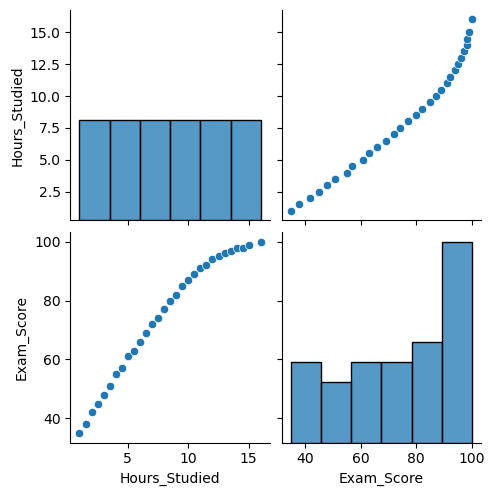

In [6]:
sns.pairplot(df)
plt.show()

In [7]:
df.head()

,Hours_Studied,Exam_Score
0,1.0,35
1,1.5,38
2,2.0,42
3,2.5,45
4,3.0,48


In [8]:
X=df[['Hours_Studied']]
y= df[['Exam_Score']]


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)

In [12]:
X_test = scaler.transform(X_test)

In [13]:
X_test

array([[ 1.62431475],
       [ 0.23655069],
       [ 1.16172673],
       [ 0.4678447 ],
       [-0.57297834],
       [-0.45733134],
       [ 1.73996176],
       [ 1.27737374]])

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
regression = LinearRegression()

In [16]:
regression.fit(X_train,y_train)

LinearRegression()

In [17]:
print(regression.coef_)

[[20.61599014]]


In [18]:
print(regression.intercept_)

[70.86363636]


In [19]:
y_pred= regression.predict(X_test)

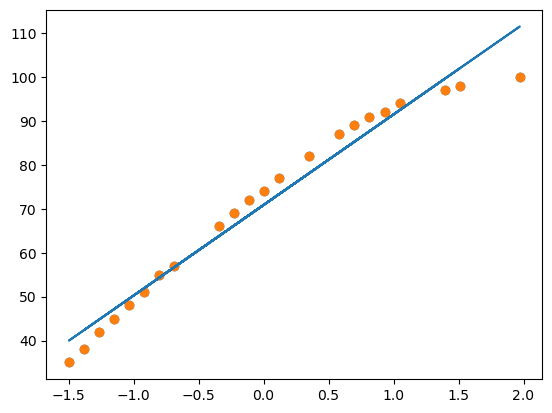

In [21]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [23]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse= np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

18.273278222741972
3.4667302218906366
4.27472551431574


In [31]:
residuals = y_test - y_pred
print(residuals)

    Exam_Score
27   -6.350493
15    4.259637
23    0.186217
17    4.491282
8     1.948879
9     1.564702
28   -7.734671
24   -1.197961


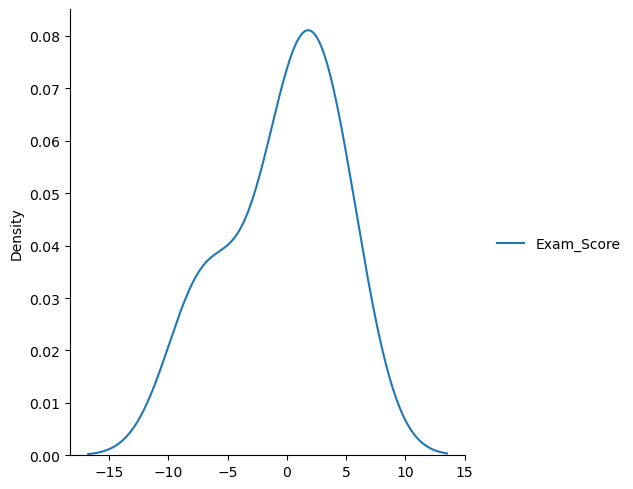

In [32]:
sns.displot(residuals, kind='kde')
plt.show()

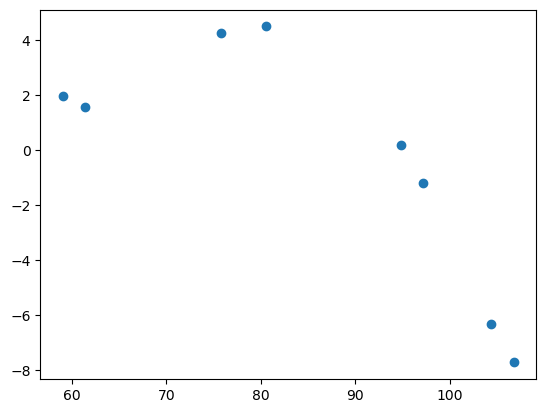

In [34]:
plt.scatter(y_pred,residuals)
plt.show()

In [24]:
from sklearn.metrics import r2_score

In [25]:
score = r2_score(y_test, y_pred)
print(score)

0.9124567852192914


In [26]:
# display adjusted R-squared
print(1- (1- score)*(len(y_test)/(len(y_test)-X_test.shape[1]-1)))

0.8832757136257219


In [28]:
import statsmodels.api as sm

In [29]:
model= sm.OLS(y_test,y_pred).fit()

In [30]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             Exam_Score   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                              2979.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):                    1.82e-10
Time:                        17:01:12   Log-Likelihood:                         -22.750
No. Observations:                   8   AIC:                                      47.50
Df Residuals:                       7   BIC:                                      47.58
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\infinix\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)
